# Notebook 1 — Exploratory Data Analysis  
## Ames Housing Dataset

### Goal of this Notebook
- how big the dataset is
- which columns are numeric vs categorical
- where the missing values are
- define the target variable 
- which features look important
- whether there are obvious outliers
- which columns may need ordinal encoding, target encoding,one hot encoding or log transforms


##  Imports and display setup

I am loading the libraries I need for quick inspection, plotting, and a few summary tables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports OK')

All imports OK


## 1. Load the raw dataset

Now I load the CSV and check its basic shape.  
Before doing any cleaning, I want to see how many rows and columns I am working with.

In [2]:
# ── Load ───────────────────────────────────────────────────────
df = pd.read_csv('train.csv')

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn dtype breakdown:')
print(df.dtypes.value_counts())

# Drop the Id column — it is just a row index, not a feature
df.drop(columns=['Id'], inplace=True)
print('\nId column dropped.')

Rows: 1,460
Columns: 81

Column dtype breakdown:
object     43
int64      35
float64     3
Name: count, dtype: int64

Id column dropped.


### Quick look at the first few rows

A small preview helps to confirm the data loaded correctly and lets me see the general structure with my own eyes.

In [3]:
# Quick peek at the first few rows
df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


### Numeric summary
  
I mainly used statistical scan of the numeric columns it spot unusual scales, extreme values, and variables that may need closer attention later.

In [4]:
# Statistical summary of all numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'max'])

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000
BsmtFinSF2,1460.000000,46.549315,161.319273,0.000000,0.000000,0.000000,0.000000,1474.000000


## Checking missing values

Here I build a proper missing-value summary instead of guessing.  
This will help me separate **structural missingness** from **true missingness** 

In [5]:
# ── Missing value summary ──────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'missing_count': missing,'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

# Label each as structural or true NA
structural_nas = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu','GarageType', 'GarageFinish', 'GarageQual', 'GarageCond','BsmtQual', 'BsmtCond', 
                  'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2','MasVnrType']
missing_df['na_type'] = missing_df.index.map(lambda c: 'Structural' if c in structural_nas else 'True NA')

missing_df.to_string()

'              missing_count  missing_pct     na_type\nPoolQC                 1453        99.52  Structural\nMiscFeature            1406        96.30  Structural\nAlley                  1369        93.77  Structural\nFence                  1179        80.75  Structural\nMasVnrType              872        59.73  Structural\nFireplaceQu             690        47.26  Structural\nLotFrontage             259        17.74     True NA\nGarageType               81         5.55  Structural\nGarageYrBlt              81         5.55     True NA\nGarageFinish             81         5.55  Structural\nGarageQual               81         5.55  Structural\nGarageCond               81         5.55  Structural\nBsmtExposure             38         2.60  Structural\nBsmtFinType2             38         2.60  Structural\nBsmtQual                 37         2.53  Structural\nBsmtCond                 37         2.53  Structural\nBsmtFinType1             37         2.53  Structural\nMasVnrArea                8

### Visual missing-value overview

A chart makes it easier to spot which columns have the biggest missing-value burden to know where the real problems are.

In [6]:
# ── Visual: missing value heatmap ─────────────────────────────
fig = px.bar(missing_df.reset_index(),x='index', y='missing_pct',color='na_type',color_discrete_map={'Structural': '#1D9E75', 'True NA': '#D85A30'},
    labels={'index': 'Column', 'missing_pct': 'Missing %', 'na_type': 'NA type'},
    title='Missing values by column — coloured by NA type')
fig.update_layout(xaxis_tickangle=-45, height=420)
fig.show()

### Decision after the missing-value review

At this point I already know that not all missing values mean the same thing.  
Some columns are missing because the feature truly does not exist for that house, while others need real imputation.

So the main takeaway is: **I should not use one blanket missing-value rule for every column.**

## Study the target: `SalePrice`

Before modeling, I want to know the distribution of target variable which will help to get an initial idea about the column.

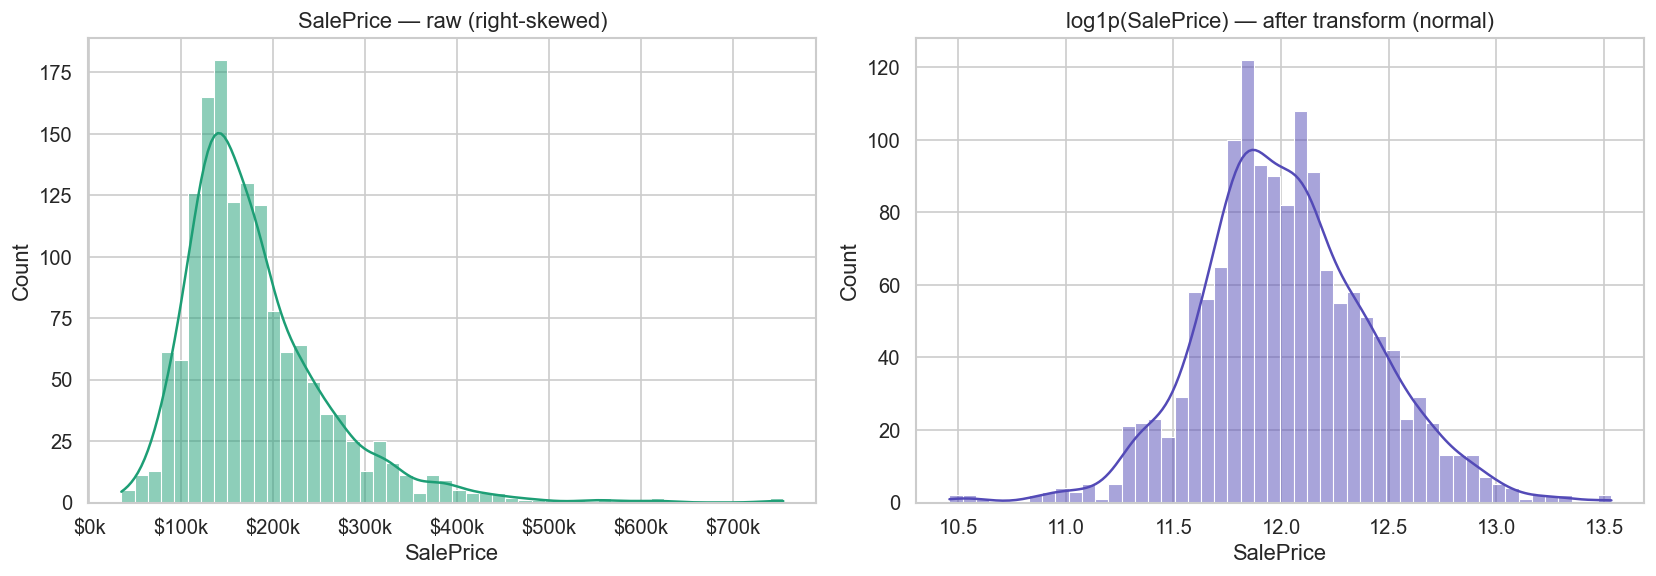

Skewness before: 1.883
Skewness after:  0.121  (closer to 0 = better)


In [7]:
# ── SalePrice: raw vs log-transformed ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#1D9E75', bins=50)
axes[0].set_title('SalePrice — raw (right-skewed)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Log-transformed
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='#534AB7', bins=50)
axes[1].set_title('log1p(SalePrice) — after transform (normal)')

plt.tight_layout()
plt.show()

print(f"Skewness before: {df['SalePrice'].skew():.3f}")
print(f"Skewness after:  {np.log1p(df['SalePrice']).skew():.3f}  (closer to 0 = better)")

### Check `SalePrice` over selling years

This gives a little more context.  
I want to see whether prices change across years and whether there is any obvious instability around the housing-market slowdown.

In [8]:
# ── SalePrice by year sold — spot the 2008 crisis ─────────────
fig = px.box(
    df, x='YrSold', y='SalePrice',
    color='YrSold',
    title='SalePrice distribution by year sold',
    labels={'YrSold': 'Year sold', 'SalePrice': 'Sale price ($)'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig.update_layout(showlegend=False, height=400)
fig.update_yaxes(tickprefix='$', tickformat=',.0f')
fig.show()
# Note: median dips in 2008-2009 — this is the financial crisis effect
# we will later use for our drift simulation

### Decision after checking the target

The target is clearly right-skewed, so using `log1p(SalePrice)` is the sensible modeling choice.
I will carry that decision into further modeling

## Correlation scan for numeric features
 
I want to see which numeric columns move most strongly with `SalePrice`.

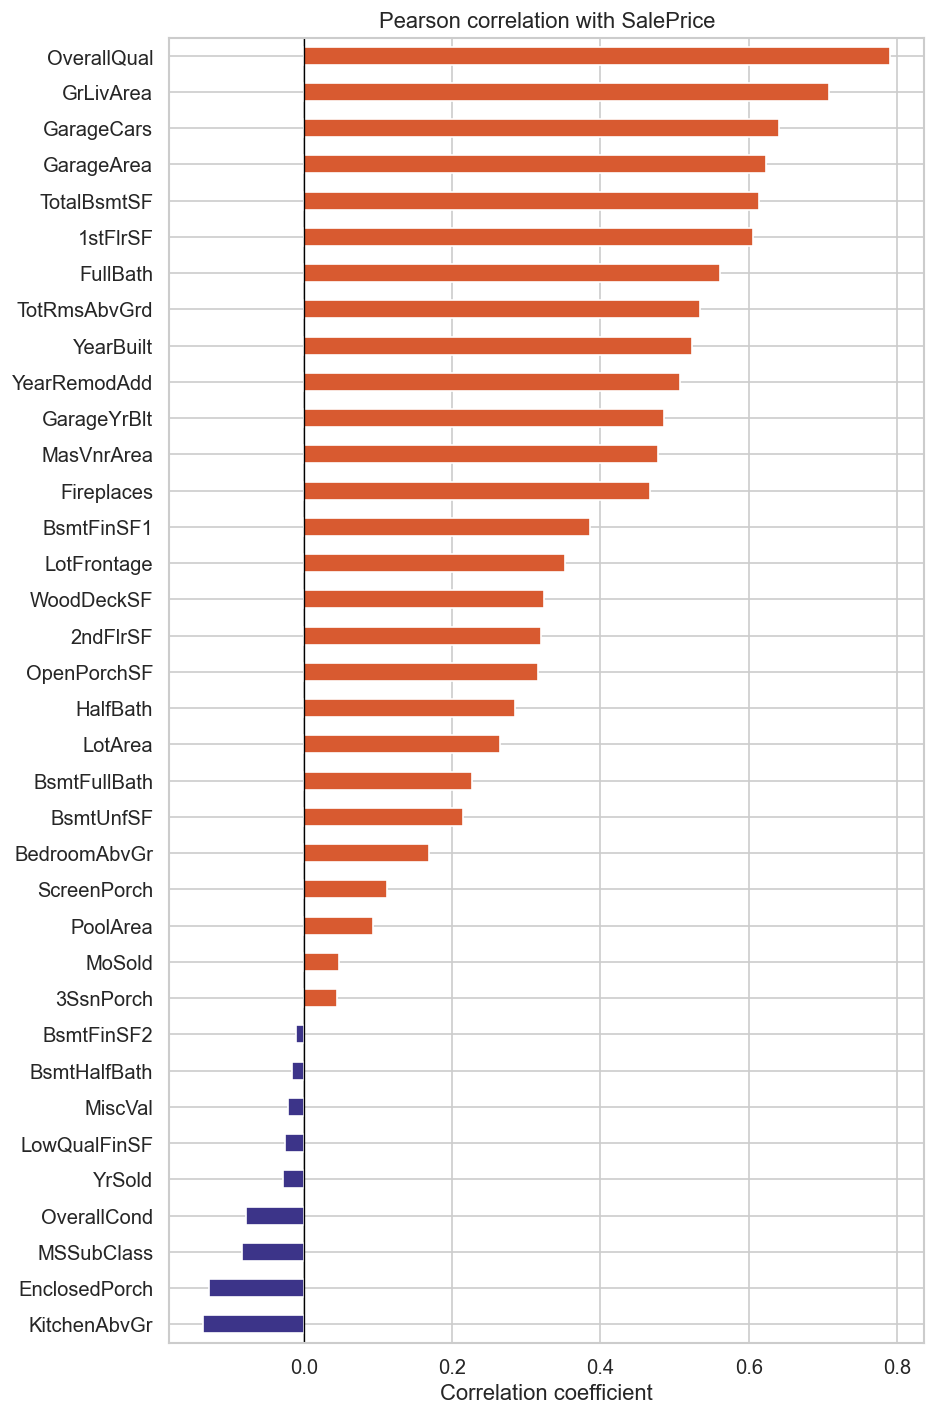

Top 10 positively correlated features:
YearRemodAdd    0.507
YearBuilt       0.523
TotRmsAbvGrd    0.534
FullBath        0.561
1stFlrSF        0.606
TotalBsmtSF     0.614
GarageArea      0.623
GarageCars      0.640
GrLivArea       0.709
OverallQual     0.791


In [9]:
# ── Correlation of numeric features with SalePrice ────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values()

fig, ax = plt.subplots(figsize=(8, 12))
colors = ['#D85A30' if v > 0 else '#3C3489' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with SalePrice')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print('Top 10 positively correlated features:')
print(corr.tail(10).round(3).to_string())

### Correlation heatmap of the strongest numeric features

A heatmap helps me see not only which features connect with price, but also which features are highly related to each other.
That is useful later for feature engineering and redundancy checks.

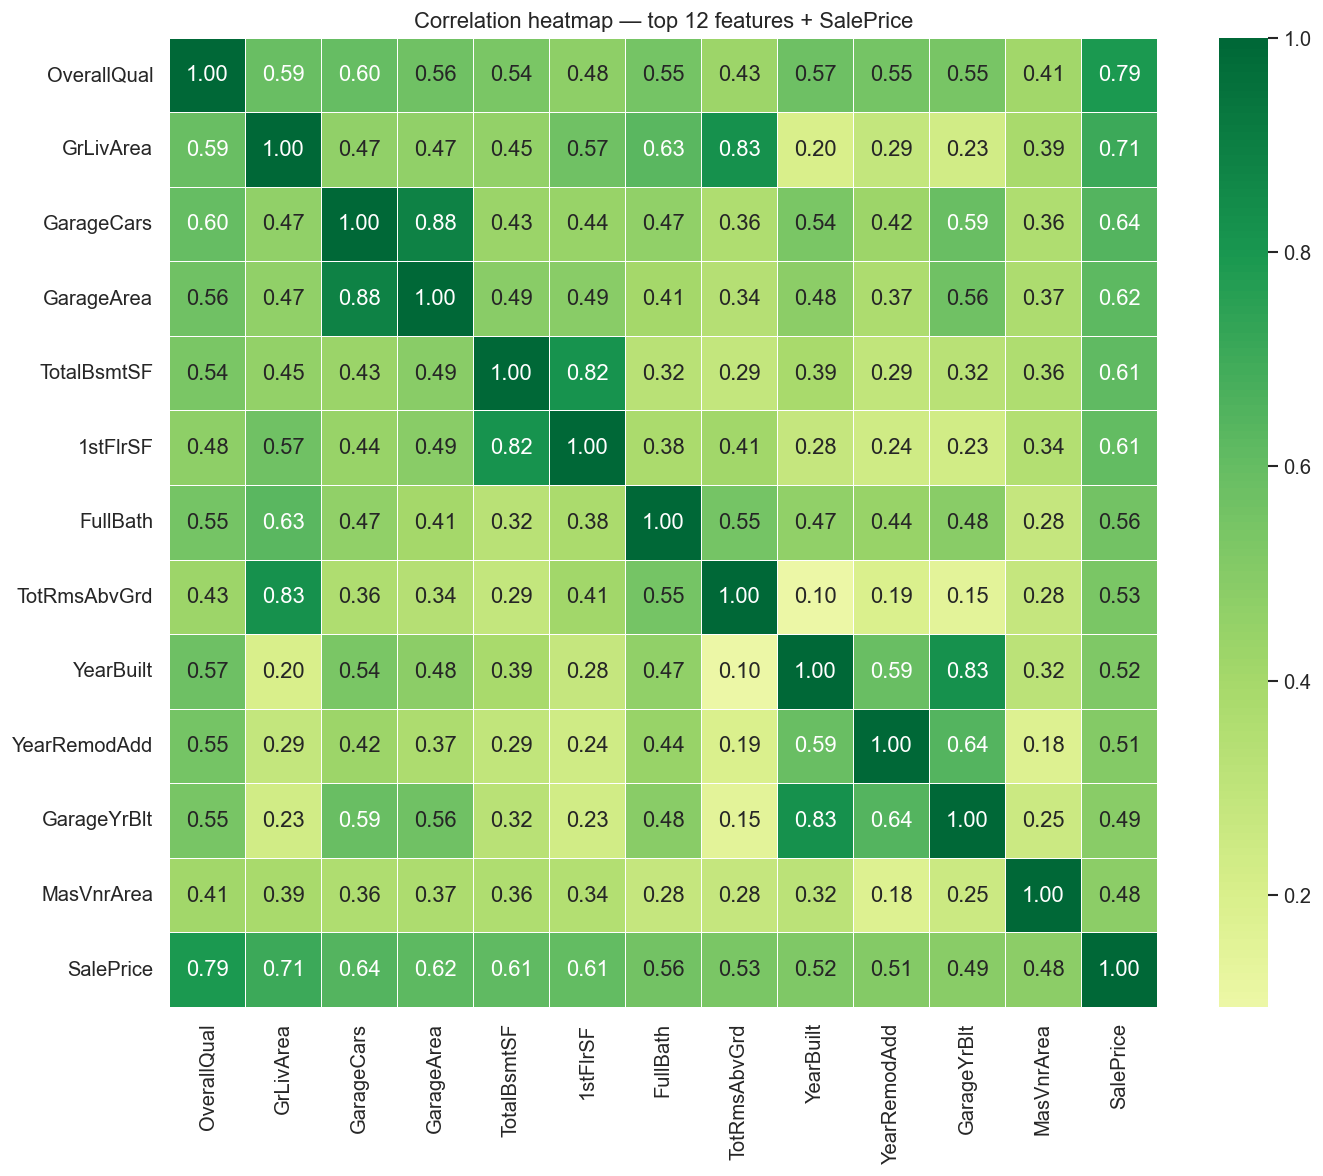

In [10]:
# ── Heatmap of the top 12 correlated features ────────────────
top_feats = corr.abs().nlargest(12).index.tolist() + ['SalePrice']

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df[top_feats].corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation heatmap — top 12 features + SalePrice')
plt.tight_layout()
plt.show()


## 5. Scatter plots for the most important numeric features

Correlation tells me the strength of a relationship.  
Scatter plots show the **shape** of that relationship and whether outliers are distorting it.

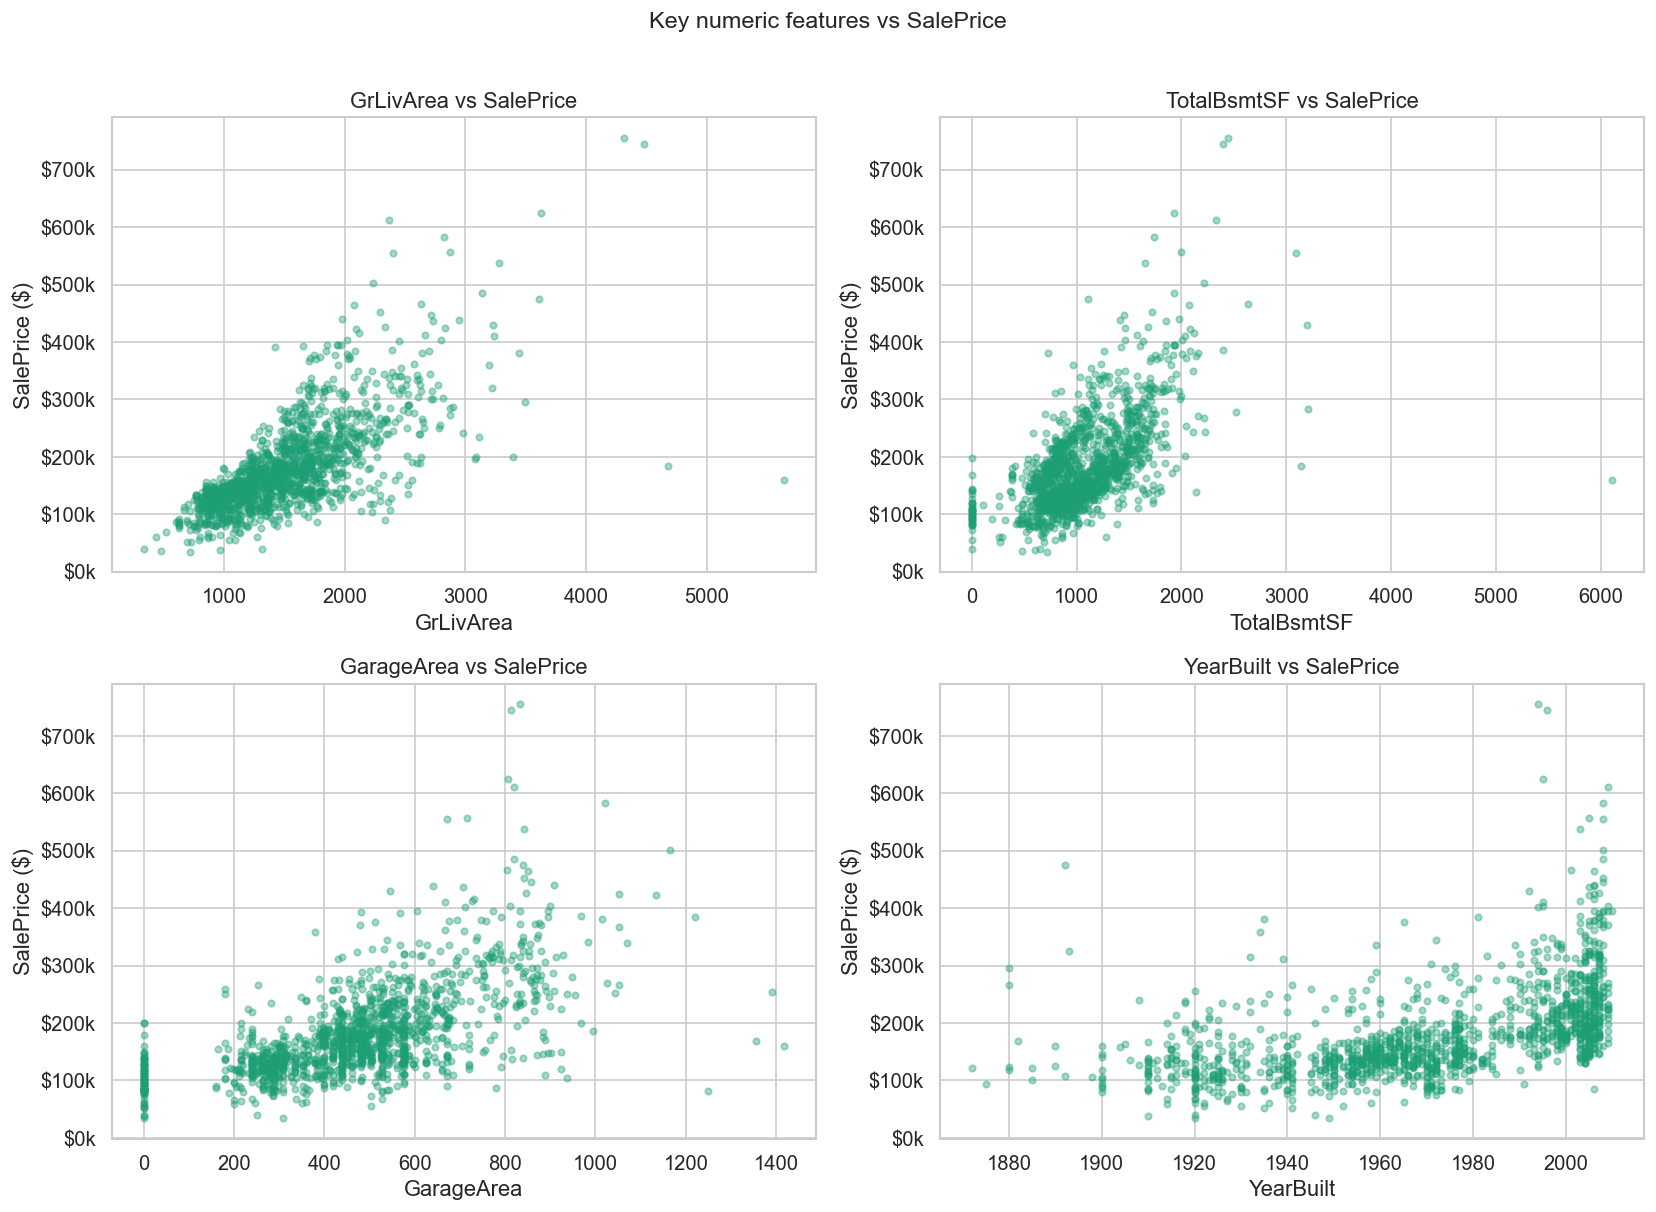

In [11]:
# ── Scatter: top 4 numeric features vs SalePrice ─────────────
top4 = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, top4):
    ax.scatter(df[col], df['SalePrice'], alpha=0.4, color='#1D9E75', s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title(f'{col} vs SalePrice')

plt.suptitle('Key numeric features vs SalePrice', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()



### Flag the famous large-house outliers

Ames has a well-known pattern where a couple of very large houses sold for surprisingly low prices.


In [12]:
# ── Flag the known outliers for reference ─────────────────────
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200_000)]
print(f'Known partial-sale outliers to remove in NB2: {len(outliers)} rows')
print(outliers[['GrLivArea', 'SalePrice', 'SaleCondition']])

Known partial-sale outliers to remove in NB2: 2 rows
      GrLivArea  SalePrice SaleCondition
523        4676     184750       Partial
1298       5642     160000       Partial


### Decision after the scatter plots

The scatter plots confirm two things:
1. a few numeric features are very important for price  
2. there are a couple of suspicious large-house outliers worth handling conservatively later


##  Look at categorical features

I want to understand which categorical variables are small enough for one-hot encoding and which ones may need a different strategy.

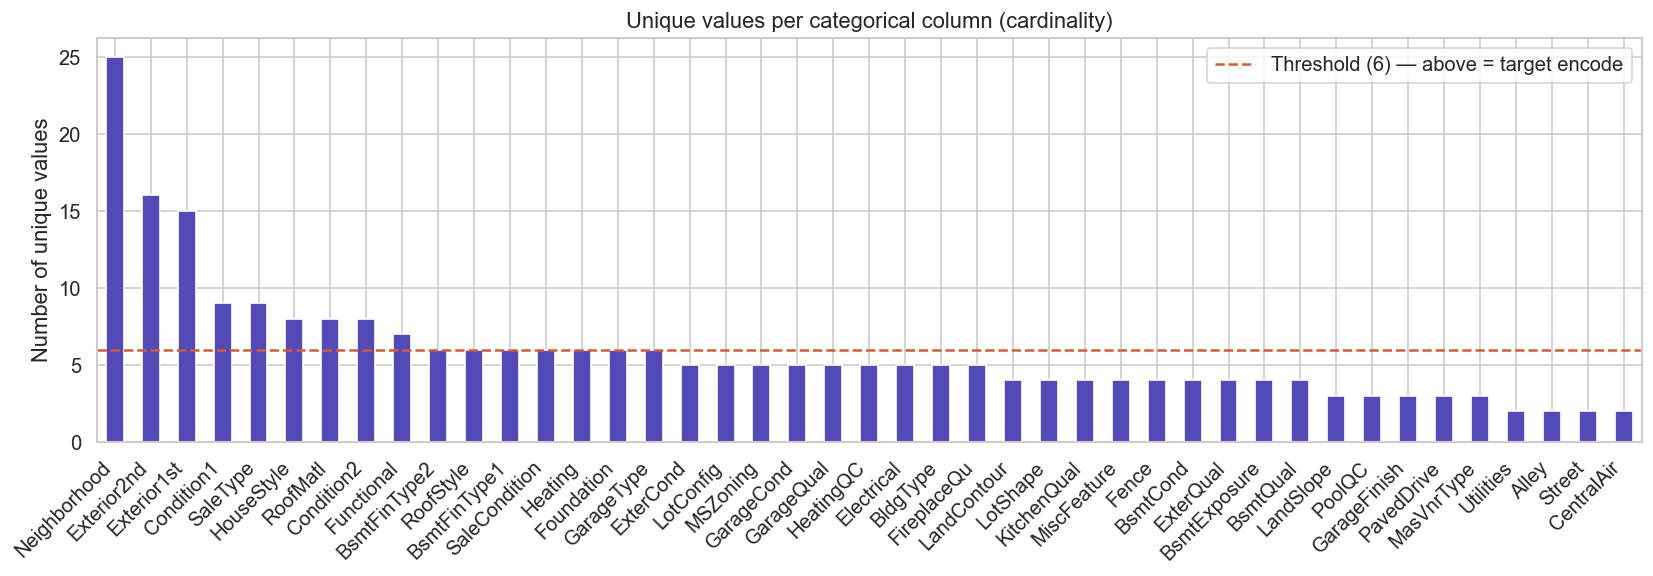

In [13]:
# ── Cardinality of all categorical columns ────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
cardinality.plot(kind='bar', ax=ax, color='#534AB7')
ax.axhline(6, color='#D85A30', linestyle='--', label='Threshold (6) — above = target encode')
ax.set_title('Unique values per categorical column (cardinality)')
ax.set_ylabel('Number of unique values')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Neighborhood effect on price

`Neighborhood` is one of the most important categorical variables in Ames.
So I want to look at it directly instead of treating it like just another text column.

In [14]:
# ── Neighborhood: highest-impact categorical feature ──────────
nbhd_price = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values()
)

fig = px.bar(
    nbhd_price.reset_index(),
    x='SalePrice', y='Neighborhood',
    orientation='h',
    title='Median SalePrice by Neighborhood',
    labels={'SalePrice': 'Median Sale Price ($)', 'Neighborhood': ''},
    color='SalePrice',
    color_continuous_scale='Teal'
)
fig.update_layout(height=600, coloraxis_showscale=False)
fig.update_xaxes(tickprefix='$', tickformat=',.0f')
fig.show()


### `OverallQual` vs price

This is one of the strongest single predictors in the dataset.
Looking at it visually helps confirm that the quality scale has a strong ordered relationship with sale price.

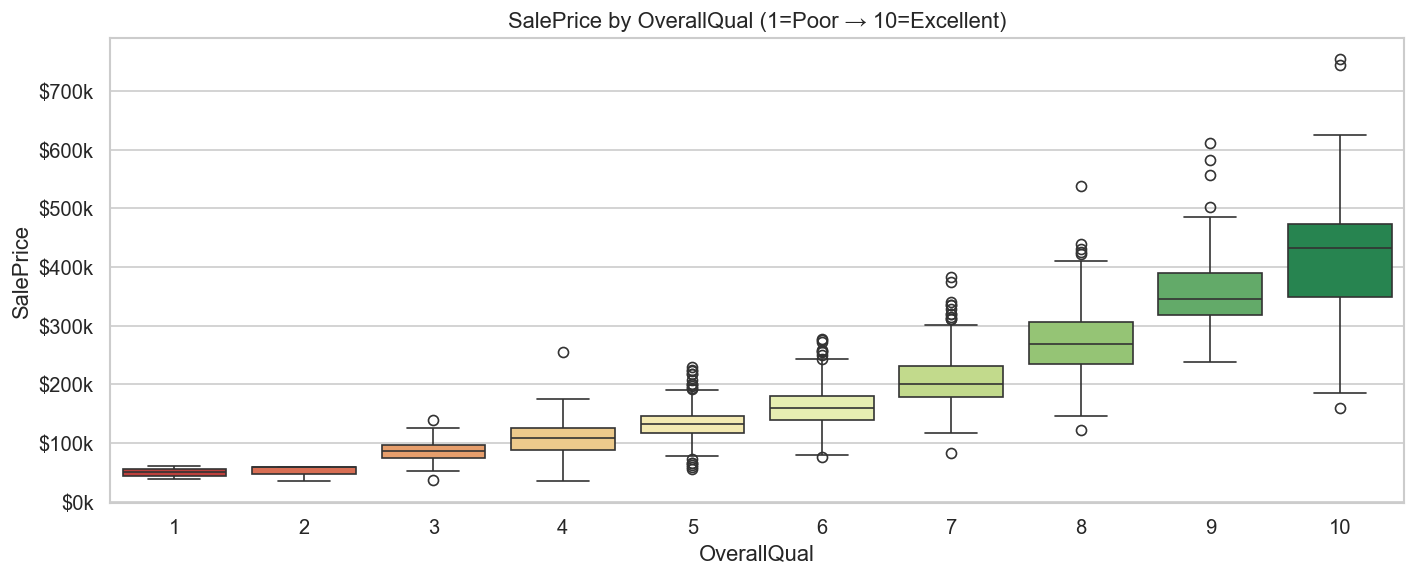

In [15]:
# ── OverallQual: strongest single predictor ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df, x='OverallQual', y='SalePrice',
    palette='RdYlGn', ax=ax
)
ax.set_title('SalePrice by OverallQual (1=Poor → 10=Excellent)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()



### Decision after the categorical review

`Neighborhood` clearly deserves special treatment, and `OverallQual` behaves like a strong ordered feature.
That tells me I will likely need a mix of **target encoding**, **ordinal mapping**, and **one-hot encoding** later.

## Spot ordinal text columns

Some columns are stored as text, but the text actually has an order like `Ex > Gd > TA > Fa > Po`.
I need to identify those now because they should not be treated like ordinary categories.

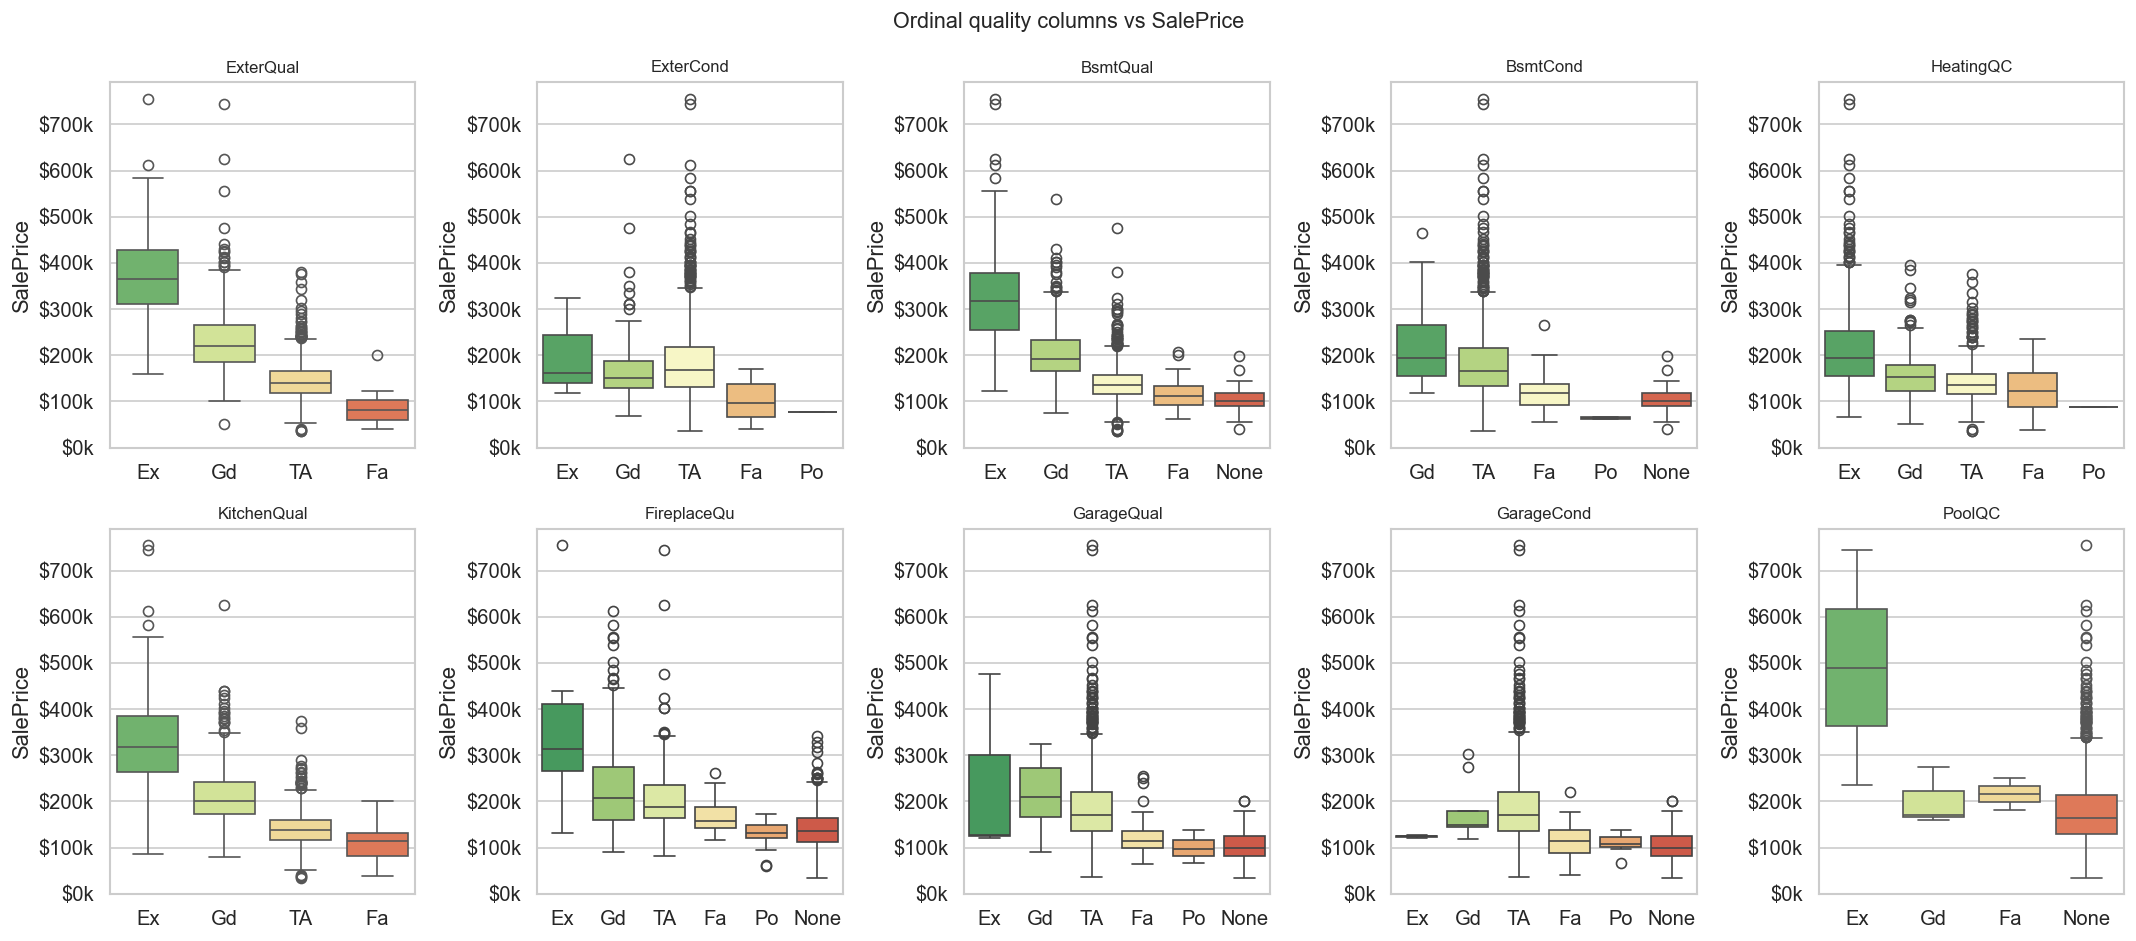

In [16]:
# ── Ordinal columns to fix ────────────────────────────────────
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

order_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

for ax, col in zip(axes.flat, ordinal_cols):
    temp = df[[col, 'SalePrice']].copy()
    temp[col] = temp[col].fillna('None')
    # Only show categories that exist in this column
    present = [k for k in ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'None'] if k in temp[col].unique()]
    sns.boxplot(
        data=temp, x=col, y='SalePrice',
        order=present, palette='RdYlGn_r', ax=ax
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Ordinal quality columns vs SalePrice', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Find skewed numeric predictors

The target is not the only thing that can be skewed.
Some predictors are also heavily right-skewed, and those are good candidates for `log1p` later.

Features with |skew| > 0.75: 21

MiscVal          24.477
PoolArea         14.828
LotArea          12.208
3SsnPorch        10.304
LowQualFinSF      9.011
KitchenAbvGr      4.488
BsmtFinSF2        4.255
ScreenPorch       4.122
BsmtHalfBath      4.103
EnclosedPorch     3.090
MasVnrArea        2.669
OpenPorchSF       2.364
LotFrontage       2.164
BsmtFinSF1        1.686
WoodDeckSF        1.541
TotalBsmtSF       1.524
MSSubClass        1.408
1stFlrSF          1.377
GrLivArea         1.367
BsmtUnfSF         0.920
2ndFlrSF          0.813


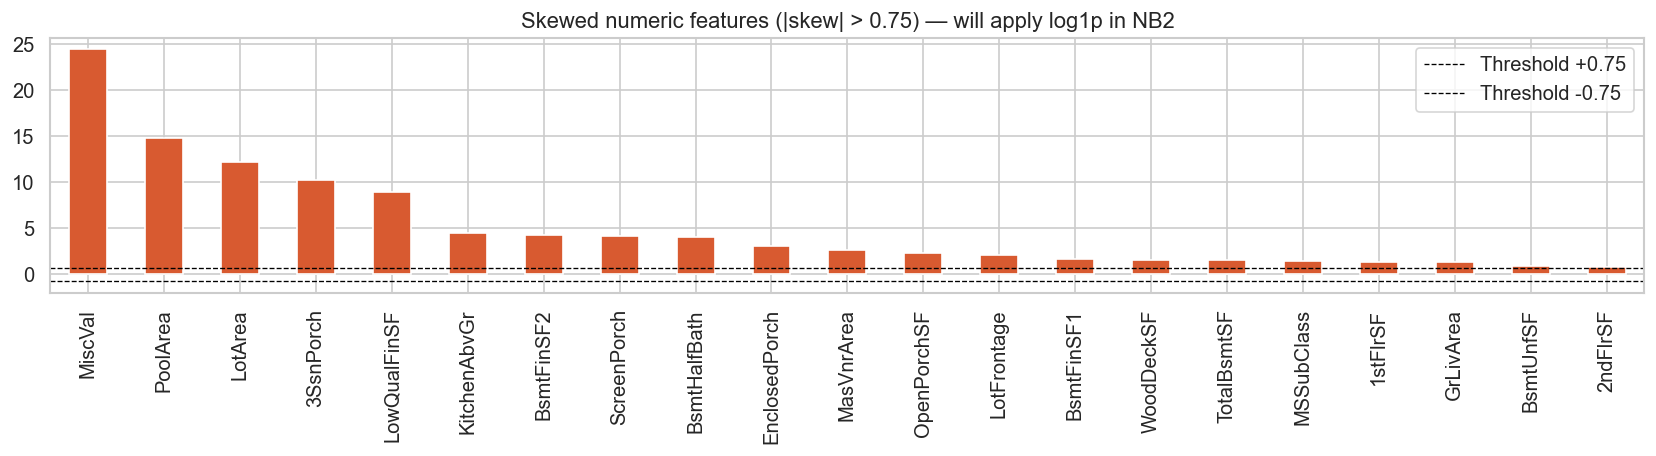

In [17]:
# ── Skewness of all numeric features ─────────────────────────
num_feats = df.select_dtypes(include=[np.number]).drop(columns=['SalePrice'])
skewness = num_feats.skew().sort_values(ascending=False)
high_skew = skewness[skewness.abs() > 0.75]

print(f'Features with |skew| > 0.75: {len(high_skew)}')
print()
print(high_skew.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#D85A30' if v > 0 else '#534AB7' for v in high_skew]
high_skew.plot(kind='bar', ax=ax, color=colors)
ax.axhline(0.75, color='black', linestyle='--', linewidth=0.8, label='Threshold +0.75')
ax.axhline(-0.75, color='black', linestyle='--', linewidth=0.8, label='Threshold -0.75')
ax.set_title('Skewed numeric features (|skew| > 0.75) — will apply log1p in NB2')
ax.legend()
plt.tight_layout()
plt.show()

### Decision after the skewness scan

Some area-related variables are strongly right-skewed, so a selective `log1p` plan makes sense.
I do not want to log everything blindly — only the columns where it actually helps.

## Save the decisions for the next notebook

I am packaging the main EDA takeaways into a small artifact so Notebook 2 can use the same plan consistently.
This keeps the workflow cleaner and more professional.

In [18]:
# ── Save column lists for Notebook 2 reference ────────────────
import json

eda_decisions = {
    'structural_na_cols': [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
        'BsmtFinType2', 'MasVnrType'
    ],
    'true_na_cols': ['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'Electrical'],
    'ordinal_cols': [
        'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
        'HeatingQC', 'KitchenQual', 'FireplaceQu',
        'GarageQual', 'GarageCond', 'PoolQC'
    ],
    'high_skew_cols': high_skew.index.tolist(),
    'high_cardinality_cols': cardinality[cardinality > 6].index.tolist()
}

with open('eda_decisions.json', 'w') as f:
    json.dump(eda_decisions, f, indent=2)

print('Saved eda_decisions.json — load this in Notebook 2.')
print(json.dumps(eda_decisions, indent=2))

Saved eda_decisions.json — load this in Notebook 2.
{
  "structural_na_cols": [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
  ],
  "true_na_cols": [
    "LotFrontage",
    "MasVnrArea",
    "GarageYrBlt",
    "Electrical"
  ],
  "ordinal_cols": [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
  ],
  "high_skew_cols": [
    "MiscVal",
    "PoolArea",
    "LotArea",
    "3SsnPorch",
    "LowQualFinSF",
    "KitchenAbvGr",
    "BsmtFinSF2",
    "ScreenPorch",
    "BsmtHalfBath",
    "EnclosedPorch",
    "MasVnrArea",
    "OpenPorchSF",
    "LotFrontage",
    "BsmtFinSF1",
    "WoodDeckSF",
    "TotalBsmtSF",
    "MSSubClass",
    "1stFlrSF",
    "GrLivAre

## Summary

By the end of this notebook, the main decisions are clear:

- treat structural and true missing values differently
- use `log1p(SalePrice)` for the target
- keep a conservative outlier rule instead of aggressive deletion
- map ordinal quality/condition columns manually
- use special handling for high-impact categorical columns like `Neighborhood`
- log-transform only the skewed numeric predictors that truly need it
